# Figure 2

LSV

run at /vento (USP)

Created: 27/01/2025 

Last update: 05/06/2026 

In [1]:
import sys # type: ignore
sys.prefix
import numpy as np # type: ignore
import xarray as xr # type: ignore
import os, glob
import pandas as pd # type: ignore
import matplotlib.pyplot as plt # type: ignore
import matplotlib.dates as mdates # type: ignore
import matplotlib.ticker as ticker # type: ignore
import matplotlib.patches as mpatches  # type: ignore
from matplotlib.gridspec import GridSpec # type: ignore
import cartopy.crs as ccrs # type: ignore
import cartopy.feature as cfeature # type: ignore
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER # type: ignore
import cmaps # type: ignore
from cmocean import cm # type: ignore
from shapely.geometry.polygon import LinearRing # type: ignore
from scipy import integrate # type: ignore
from scipy import stats # type: ignore
from scipy import signal # type: ignore
from scipy.stats import pearsonr # type: ignore
from scipy.stats import ttest_ind # type: ignore
import seaborn as sns # type: ignore
import cftime # type: ignore
import nc_time_axis # type: ignore
from scipy.ndimage import binary_erosion
degree_sign= u'\N{DEGREE SIGN}'

In [2]:
def xr_CI(data_array, signif=0.95, dim=None):
    from scipy.stats import t # type: ignore
    """
    Calculate the confidence interval of a DataArray along a specified dimension.

    Parameters:
    data_array (xarray.DataArray): The DataArray to compute the confidence interval on.
    confidence (float): The confidence level, between 0 and 1. Default is 0.95.
    dim (str or None): The dimension along which to calculate the confidence interval. 
                       If None, will compute over the entire dataset.

    Returns:
    xarray.DataArray: A DataArray containing the lower and upper bounds of the confidence interval.
    """
    mean = data_array.mean(dim)
    std = data_array.std(dim)
    n = data_array.count(dim)
    se = std / np.sqrt(n)
    h = se * t.ppf((1 + signif) / 2., n - 1)

    lower_bound = mean - h
    upper_bound = mean + h
    return xr.Dataset({'lb': lower_bound, 'ub': upper_bound})

In [3]:
def stippling_1st_derivative(data,nivel):
    #media ens
    y=data.mean(axis=-1)
    #calcular a 1a derivada p cada ens [n+1]-[n]
    diff=np.diff(data,axis=0)
    #adicionar um 0 no começo da serie de diffs de cada ens
    zeros_to_add = np.zeros((1, diff.shape[1]))
    diff_with_zero = np.concatenate([zeros_to_add, diff], axis=0)
    #ver numero de memb onde a 1a derivada é positiva
    no_pos=np.sum(diff_with_zero>0,axis=-1)
    #ver numero de memb onde a 1a derivada é negativa
    no_neg=np.sum(diff_with_zero<=0,axis=-1)
    N = round(data.shape[-1]*nivel/100)
    scatter_x=data.time[(no_pos>=N)+(no_neg>=N)]
    scatter_y=y[(no_pos>=N)+(no_neg>=N)]
    return scatter_x, scatter_y

In [4]:
def stippling_signal_agreement(data,nivel):
    #data = tosMod #np.stack(mv_std_modelos)
    nPos=np.sum(data>=0, axis=-1) # check where the anomaly is positive (sum)
    nNeg=np.sum(data<0, axis=-1) # check where the anomaly is negative
    N = round(data.shape[1]*nivel*.01) # calculates the number of events for reference
    
    if data.dims[0] == 'time':
        scatter_x=data.time[(nPos>=N)+(nNeg>=N)] # create dots to plot (time vs. anomaly)
    elif data.dims[0] == 'year':
        scatter_x=data.year[(nPos>=N)+(nNeg>=N)] # create dots to plot (time vs. anomaly)
    if data.dims[1] == 'ensemble':
        scatter_y=data.mean('ensemble')[(nPos>=N)+(nNeg>=N)]
    elif data.dims[1] == 'record':
        scatter_y=data.mean('record')[(nPos>=N)+(nNeg>=N)]
    
    return scatter_x, scatter_y

In [5]:
def calculate_linear_trend(values): # for variable with time not year
    # Calculate linear fit coefficients
    coeffs = np.polyfit(values.time, values.values, 1)
    slope, intercept = coeffs

    # Predict values using the linear model
    model_predictions = np.polyval([slope, intercept], values.time)

    # Calculate residuals and statistical measures
    residuals = values.values - model_predictions
    ss_res = np.sum(residuals**2)
    ss_tot = np.sum((values.values - np.mean(values.values))**2)
    r_squared = 1 - (ss_res / ss_tot)
    degrees_of_freedom = len(values) - 2
    stderr = np.sqrt(ss_res / degrees_of_freedom) / np.sqrt(np.sum((values.time - np.mean(values.time))**2))
    t_stat = slope / stderr
    p_value = stats.t.sf(np.abs(t_stat), degrees_of_freedom) * 2  # two-tailed p-value

    # Output the results
    trend_line = slope * values.time + intercept
    print(f"Linear trend: slope = {slope:.3f} (units/year), intercept = {intercept:.3f}")
    print(f"R-squared: {r_squared:.3f}, p-value: {p_value:.3g}")

    return slope, intercept, r_squared, p_value, trend_line

In [6]:
PathDataSets = '/bolha/wk2/laura/dataIPSLpast2k/'
PathDataSetsRaw = '/bolha/wk2/IPSLpast2k/'
PathFigures = '/home/laura/figures/STC/draft_figures/review1'

In [7]:
slice_clim =slice('1850','1900')
clim_ref = '1850-1900'

In [8]:
plt.rcParams['font.size'] = 14

## * Meridional Ekman transport

In [9]:
# load tauu
dsTAUU = xr.open_dataset(PathDataSetsRaw+'tauu/tauu_Amon_CM65-LR-past2k-members-1-10_gr_050001-201412.nc')
dsTAUUsel = dsTAUU.sel(lon=slice(-65, 25),lat=slice(-35,35))

In [10]:
# tauu mask based on SST
dsSST = xr.open_dataset(PathDataSets+'thetao/thetao_Omon_AtlSfc_CM65-LR-past2k-all_gr_050001-201412.nc')
mask_ocean = dsSST.thetao.notnull().any(dim=["record", "time"]).sortby("lat").compute()
mask_ocean = mask_ocean.assign_coords(lat=dsTAUUsel.lat,lon=dsTAUUsel.lon)
dsTAUUsel_masked = dsTAUUsel.tauu.where(mask_ocean)

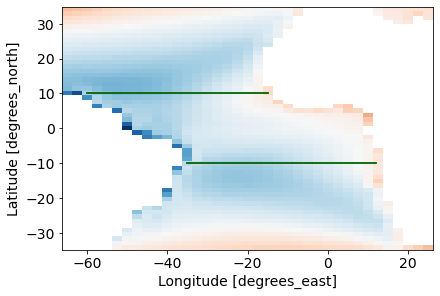

In [11]:
# check mask
fig, axes = plt.subplots(1, 1, constrained_layout=True)

dsTAUUsel_masked.mean(dim=['time','ensemble']).plot(x='lon',
        y='lat',
        cmap='RdBu_r',
       add_colorbar=False)

lat_line = np.linspace(-60, -15, 37)
lon_line = np.full_like(lat_line, 10)
axes.plot(lat_line,lon_line, color='darkgreen',lw=1.8, zorder=120)

lat_line = np.linspace(-35, 12, 37)
lon_line = np.full_like(lat_line, -10)
axes.plot(lat_line,lon_line, color='darkgreen',lw=1.8, zorder=120)

In [12]:
# Constants for Ekman
rho = 1025  # Density of seawater in kg/m^3
omega = 7.2921e-5  # Earth's angular velocity in rad/s

def coriolis_parameter(latitude):
    """Calculate the Coriolis parameter for a given latitude."""
    return 2 * omega * np.sin(np.radians(latitude))

def ekman_transport(tau, f):
    """Calculate the Ekman transport."""
    return - tau / (rho * f)

earth_radius = 6371000  # Earth's radius in meters

def distance_per_longitude_degree(latitude):
    """Calculate the distance in meters for one degree of longitude at a given latitude."""
    return np.pi * earth_radius * np.cos(np.radians(latitude)) / 180

In [13]:
# 10N
closest_lat = dsTAUUsel_masked.lat[np.abs(dsTAUUsel_masked.lat - 10).argmin()].item()
#print(closest_lat)
tauu10N = dsTAUUsel_masked.sel(lat = closest_lat,lon = slice(-60,-15)) 
 
fN = coriolis_parameter(tauu10N.lat.values)
m10N = ekman_transport(tauu10N, fN)

d10N = distance_per_longitude_degree(tauu10N.lat.values) # 1 deg long (at 10N lat) in meters 
dlon = tauu10N.lon.diff('lon') # long distance in degrees
dlon_to_meters = dlon*d10N # long distance in meters 

# Integrate transport along the longtude from 60 to 15W
EK10Nsv = (m10N.sel(lon=slice(-60,-15)).sum('lon') * dlon_to_meters[0])/1e6 # ekman merid transp in Sv

# Compute anomaly
anomEKn = EK10Nsv.groupby('time.month') - EK10Nsv.sel(time=slice_clim).groupby('time.month').mean('time')

In [14]:
# 10S
closest_lat = dsTAUUsel_masked.lat[np.abs(dsTAUUsel_masked.lat - (-10)).argmin()].item()
tauu10S = dsTAUUsel_masked.sel(lat = closest_lat,lon = slice(-35,12))

f = coriolis_parameter(tauu10S.lat.values)
m10S = ekman_transport(tauu10S, f)

d10S = distance_per_longitude_degree(tauu10S.lat.values) # 1 deg long (at 10N lat) in meters 
dlon = tauu10S.lon.diff('lon') # long distance in degrees
dlon_to_meters = dlon*d10S # long distance in meters 

# Integrate transport along the longtude from 60 to 15W
EK10Ssv = (m10S.sel(lon=slice(-35,12)).sum('lon') * dlon_to_meters[0])/1e6 # ekman merid transp in Sv

# Invert the EK transport in the south (both are positive pointing to south)
EK10SsvINV = EK10Ssv*-1 

# Compute anomaly
anomEKs = EK10Ssv.groupby('time.month') - EK10Ssv.sel(time=slice_clim).groupby('time.month').mean('time')
anomEKsINV = EK10SsvINV.groupby('time.month') - EK10SsvINV.sel(time=slice_clim).groupby('time.month').mean('time')

In [15]:
# Poleward Ekman transport ANOMALY 10yr running avg
# 10N
anomEKn_smooth = anomEKn.coarsen(time=12).mean().rolling(time=10).mean().rolling(time=10).mean() # IPSL
anomEKn_smooth2 = anomEKn_smooth.assign_coords(time=np.arange(500, 2015)) # change time axis
anomEKn_std = anomEKn_smooth.mean('ensemble').std('time')
anomEKn_avg = anomEKn_smooth.mean('ensemble').mean('time')

# 10S
anomEKs_smooth = anomEKsINV.coarsen(time=12).mean().rolling(time=10).mean().rolling(time=10).mean() # IPSL
anomEKs_smooth2 = anomEKs_smooth.assign_coords(time=np.arange(500, 2015)) # change time axis
anomEKsINV_std =  anomEKs_smooth.mean('ensemble').std('time')
anomEKsINV_avg =  anomEKs_smooth.mean('ensemble').mean('time')

In [16]:
# Poleward Ekman transport FULL 10yr running avg
# 10N
EKn_smooth = EK10Nsv.coarsen(time=12).mean().rolling(time=10).mean().rolling(time=10).mean() # IPSL
EKn_smooth2 = EKn_smooth.assign_coords(time=np.arange(500, 2015)) # change time axis
EKn_std = EKn_smooth.mean('ensemble').std('time')
EKn_avg = EKn_smooth.mean('ensemble').mean('time')

# 10S
EKs_smooth = EK10SsvINV.coarsen(time=12).mean().rolling(time=10).mean().rolling(time=10).mean() # IPSL
EKs_smooth2 = EKs_smooth.assign_coords(time=np.arange(500, 2015)) # change time axis
EKsINV_std =  EKs_smooth.mean('ensemble').std('time')
EKsINV_avg =  EKs_smooth.mean('ensemble').mean('time')

In [17]:
# trends 1850-2015
print('Trend 1850-2015')
print(' ')
print('Trend NH (10N, 60W-15W):')
EKslopeN, EKintercept, EKr_squared, EKp_value, EKtrend_lineN = calculate_linear_trend(anomEKn_smooth2.mean('ensemble').sel(time=slice(1850,2015)).dropna(dim='time') )
val1850 = EKtrend_lineN.sel(time=1850, method="nearest")
val2015 = EKtrend_lineN.sel(time=2015, method="nearest")
print(f"EKn Value 1850: {val1850.values}, value 2015 {val2015.values}")
delta = val2015 - val1850
print(f"Absolute change in EKn from 1850 to 2015: {delta.values}")

print(' ')
print('Trend SH (10S, 35W-10E):')
EKslopeS, EKintercept, EKr_squared, EKp_value, EKtrend_lineS = calculate_linear_trend(anomEKs_smooth2.mean('ensemble').sel(time=slice(1850,2015)).dropna(dim='time') )
val1850 = EKtrend_lineS.sel(time=1850, method="nearest")
val2015 = EKtrend_lineS.sel(time=2015, method="nearest")
print(f"EKs Value 1850: {val1850.values}, value 2015 {val2015.values}")
delta = val2015 - val1850
print(f"Absolute change in EKs from 1850 to 2015: {delta.values}")

Trend 1850-2015
 
Trend NH (10N, 60W-15W):
Linear trend: slope = -0.005 (units/year), intercept = 10.005
R-squared: 0.916, p-value: 1.35e-89
EKn Value 1850: 0.1888037123728612, value 2015 -0.6813567153238811
Absolute change in EKn from 1850 to 2015: -0.8701604276967423
 
Trend SH (10S, 35W-10E):
Linear trend: slope = 0.002 (units/year), intercept = -2.975
R-squared: 0.475, p-value: 1.49e-24
EKs Value 1850: -0.021804078223504053, value 2015 0.2400163516525673
Absolute change in EKs from 1850 to 2015: 0.26182042987607135


In [18]:
# trends 1920-2015
print('Trend 1920-2015')
print(' ')
print('Trend NH (10N, 60W-15W):')
slopeN2, intercept2, r_squared2, p_value2, trend_lineN2 = calculate_linear_trend(anomEKn_smooth2.mean('ensemble').sel(time=slice(1920,2015)).dropna(dim='time') )
val1920 = trend_lineN2.sel(time=1920, method="nearest")
val2015 = trend_lineN2.sel(time=2015, method="nearest")
print(f"EKn Value 1920: {val1920.values}, value 2015 {val2015.values}")
delta2 = val2015 - val1920
print(f"Absolute change in EKn from 1920 to 2015: {delta2.values}")

print(' ')
print('Trend SH (10S, 35W-10E):')
slopeS2, intercept2, r_squared2, p_value2, trend_lineS2 = calculate_linear_trend(anomEKs_smooth2.mean('ensemble').sel(time=slice(1920,2015)).dropna(dim='time') )
val1920 = trend_lineS2.sel(time=1920, method="nearest")
val2015 = trend_lineS2.sel(time=2015, method="nearest")
print(f"EKs Value 1920: {val1920.values}, value 2015 {val2015.values}")
delta2 = val2015 - val1920
print(f"Absolute change in EKs from 1920 to 2015: {delta2.values}")

Trend 1920-2015
 
Trend NH (10N, 60W-15W):
Linear trend: slope = -0.007 (units/year), intercept = 12.478
R-squared: 0.872, p-value: 2.95e-43
EKn Value 1920: -0.12333925314960936, value 2015 -0.7402757774337339
Absolute change in EKn from 1920 to 2015: -0.6169365242841245
 
Trend SH (10S, 35W-10E):
Linear trend: slope = 0.001 (units/year), intercept = -2.582
R-squared: 0.292, p-value: 1.56e-08
EKs Value 1920: 0.11654554627296632, value 2015 0.248657664203233
Absolute change in EKs from 1920 to 2015: 0.13211211793026667


## * Ekman divergence

In [19]:
# Total Ekman divergence (+EKn) - (-EKs) same as abs(EKn) + abs(EKs)
EKdiv = abs(EK10Ssv) + abs(EK10Nsv)
#anomEKdiv = EKdiv.groupby('time.month') - EKdiv.sel(time=slice_clim).groupby('time.month').mean('time')
#anomEKdiv_smooth = anomEKdiv.coarsen(time=12).mean().rolling(time=10).mean().rolling(time=10).mean() # Yearly and smooth running 10yr avg
#anomEKdiv_smooth2 = anomEKdiv_smooth.assign_coords(time=np.arange(500, 2015)) # change time axis
EKdiv_smooth = EKdiv.coarsen(time=12).mean().rolling(time=10).mean().rolling(time=10).mean() # Yearly and smooth running 10yr avg
EKdiv_smooth2 = EKdiv_smooth.assign_coords(time=np.arange(500, 2015)) # change time axis
EKdiv_std = EKdiv_smooth2.mean('ensemble').std('time')
EKdiv_avg = EKdiv_smooth2.mean('ensemble').mean('time')

print('Trend Ekman Divergence:')
DIVslope, DIVintercept, DIVr_squared, DIVp_value, DIVtrend_line = calculate_linear_trend(EKdiv_smooth2.mean('ensemble').sel(time=slice(1850,2015)).dropna(dim='time') )
val1850 = DIVtrend_line.sel(time=1850, method="nearest")
val2015 = DIVtrend_line.sel(time=2015, method="nearest")
print(f"Div Value 1850: {val1850.values}, value 2015 {val2015.values}")
delta = val2015 - val1850
print(f"Absolute change in Ekman Div from 1850 to 2015: {delta.values}")

Trend Ekman Divergence:
Linear trend: slope = -0.004 (units/year), intercept = 31.648
R-squared: 0.836, p-value: 6.99e-66
Div Value 1850: 24.749508953198937, value 2015 24.13795144330763
Absolute change in Ekman Div from 1850 to 2015: -0.6115575098913055


## * Annual subduction rate

In [20]:
dsVh = xr.open_dataset(PathDataSets+"vo/vo_Omon_MLD_CM65-LR-past2k-all_gr_050001-201412.nc")
dsUh = xr.open_dataset(PathDataSets+"uo/uo_Omon_MLD_CM65-LR-past2k-all_gr_050001-201412.nc")
dsWh = xr.open_dataset(PathDataSets+"wo/wo_Omon_MLD_CM65-LR-past2k-all_gr_050001-201412.nc")

In [21]:
vH = dsVh.vo.groupby('time.year').mean('time') # annual averages
uH = dsUh.uo.groupby('time.year').mean('time') # annual averages
wH = dsWh.wo.groupby('time.year').mean('time') # annual averages
H = dsVh.mld.groupby('time.year').mean('time') # annual averages

lat = dsVh.lat
lon = dsVh.lon

In [22]:
# Convert degrees to radians for gradient calculation
lat_rad = np.deg2rad(lat)
lon_rad = np.deg2rad(lon)

# Calculate the change in meters for a degree change in latitude and longitude
radius_earth = 6371e3  # in meters
delta_x = np.cos(lat_rad) * np.pi/180 * radius_earth
delta_y = np.pi/180 * radius_earth

# Compute gradients (approximate, using central differences for interior points)
grad_H_x = H.diff('lon') / delta_x 
grad_H_y = H.diff('lat') / delta_y  # Change in H per meter in the y (north-south) direction

# Since we lost one point in the gradient calculation, adjust the velocity arrays accordingly
uH_adjusted = uH[:, :, 1:,:]  # Adjust for the lost longitude point in grad_H_x
vH_adjusted = vH[:, 1:, :,:]  # Adjust for the lost latitude point in grad_H_y
wH_adjusted = wH[:, 1:, 1:,:]  # Adjust for both

# Dot product VH * ∇H, assuming grad_H_x and grad_H_y align with uH and vH directions respectively
dot_product = (uH_adjusted * grad_H_x) + (vH_adjusted * grad_H_y)

# Calculate S_ann = -(VH . ∇H + wH)
S_ann_mS = -(dot_product + wH_adjusted)

# Convert from m/s to m/yr
S_ann_mYr = S_ann_mS * 60 * 60 * 24 * 365.25

# Rename year to time
S_ann_mYr2 = S_ann_mYr.rename({"year": "time"})

In [23]:
# 1. Ocean mask
mask_ocean = S_ann_mYr2.notnull().any(dim=['time', 'record'])

# 2. Remove 2 coastal grid cells
mask_open_ocean = xr.DataArray(
    binary_erosion(mask_ocean.values, structure=np.ones((3, 3)), iterations=2),
    coords=mask_ocean.coords,
    dims=mask_ocean.dims)

# 3. Apply open-ocean mask
S_open = S_ann_mYr2.where(mask_open_ocean)

In [24]:
# 1. Keep only positive subduction
S_pos = S_open.where(S_open > 0)

# 2. Basin means
NA_basin = (
    S_pos
    .sel(lat=slice(30, 0), lon=slice(-62.5, 25))
    .mean(dim=['lat', 'lon']))

SA_basin = (
    S_pos
    .sel(lat=slice(0, -30), lon=slice(-62.5, 25))
    .mean(dim=['lat', 'lon']))

In [25]:
# Subduction North
NAsub = NA_basin - NA_basin.sel(time=slice_clim).mean('time')
NorthAtlanticSubduction_smooth = NAsub.rolling(time=10).mean().rolling(time=10).mean()
NorthAtlanticSubduction_smooth2 = NorthAtlanticSubduction_smooth.assign_coords(time=np.arange(500, 2015)) # change time axis
subNorth_std = NorthAtlanticSubduction_smooth.mean('record').std('time')
subNorth_avg = NorthAtlanticSubduction_smooth.mean('record').mean('time')

# Subduction South
SAsub = SA_basin - SA_basin.sel(time=slice_clim).mean('time')
SouthAtlanticSubduction_smooth = SAsub.rolling(time=10).mean().rolling(time=10).mean()
SouthAtlanticSubduction_smooth2 = SouthAtlanticSubduction_smooth.assign_coords(time=np.arange(500, 2015)) # change time axis
subSouth_std = SouthAtlanticSubduction_smooth.mean('record').std('time')
subSouth_avg = SouthAtlanticSubduction_smooth.mean('record').mean('time')

In [26]:
# trends 1850-2015
print('Trend 1850-2015')
print(' ')
print('Trend NH:')
SUBslopeN, SUBintercept, SUBr_squared, SUBp_value, SUBtrend_lineN = calculate_linear_trend(NorthAtlanticSubduction_smooth2.mean('record').sel(time=slice(1850,2015)).dropna(dim='time') )
val1850 = SUBtrend_lineN.sel(time=1850, method="nearest")
val2015 = SUBtrend_lineN.sel(time=2015, method="nearest")
print(f"Nsub Value 1850: {val1850.values}, value 2015 {val2015.values}")
delta = val2015 - val1850
print(f"Absolute change in Nsub from 1850 to 2015: {delta.values}")
print(' ')
print('Trend SH:')
SUBslopeS, SUBintercept, SUBr_squared, SUBp_value, SUBtrend_lineS = calculate_linear_trend(SouthAtlanticSubduction_smooth2.mean('record').sel(time=slice(1850,2015)).dropna(dim='time') )
val1850 = SUBtrend_lineS.sel(time=1850, method="nearest")
val2015 = SUBtrend_lineS.sel(time=2015, method="nearest")
print(f"Ssub Value 1850: {val1850.values}, value 2015 {val2015.values}")
delta = val2015 - val1850
print(f"Absolute change in Ssub from 1850 to 2015: {delta.values}")

Trend 1850-2015
 
Trend NH:
Linear trend: slope = -0.014 (units/year), intercept = 26.213
R-squared: 0.350, p-value: 6.16e-17
Nsub Value 1850: 0.8733902184946096, value 2015 -1.3729655619568888
Absolute change in Nsub from 1850 to 2015: -2.2463557804514984
 
Trend SH:
Linear trend: slope = 0.014 (units/year), intercept = -26.195
R-squared: 0.272, p-value: 6.79e-13
Ssub Value 1850: 0.1293042591756226, value 2015 2.4629289322944707
Absolute change in Ssub from 1850 to 2015: 2.333624673118848


In [29]:
# trends 1920-2015
print('Trend 1920-2015')
print(' ')
print('Trend NH:')
slopeN2, intercept2, r_squared2, p_value2, trend_lineN2 = calculate_linear_trend(NorthAtlanticSubduction_smooth2.mean('record').sel(time=slice(1920,2015)).dropna(dim='time') )
val1920 = trend_lineN2.sel(time=1920, method="nearest")
val2015 = trend_lineN2.sel(time=2015, method="nearest")
print(f"Nsub Value 1920: {val1850.values}, value 2015 {val2015.values}")
delta2 = val2015 - val1920
print(f"Absolute change in Nsub from 1920 to 2015: {delta2.values}")

print(' ')
print('Trend SH:')
slopeS2, intercept2, r_squared2, p_value2, trend_lineS2 = calculate_linear_trend(SouthAtlanticSubduction_smooth2.mean('record').sel(time=slice(1920,2015)).dropna(dim='time') )
val1920 = trend_lineS2.sel(time=1920, method="nearest")
val2015 = trend_lineS2.sel(time=2015, method="nearest")
print(f"Ssub Value 1920: {val1850.values}, value 2015 {val2015.values}")
delta2 = val2015 - val1920
print(f"Absolute change in Ssub from 1920 to 2015: {delta.values}")

Trend 1920-2015
 
Trend NH:
Linear trend: slope = -0.037 (units/year), intercept = 72.203
R-squared: 0.779, p-value: 3.17e-32
Nsub Value 1920: 0.1293042591756226, value 2015 -2.2233559615503395
Absolute change in Nsub from 1920 to 2015: -3.473722059339508
 
Trend SH:
Linear trend: slope = 0.004 (units/year), intercept = -5.105
R-squared: 0.010, p-value: 0.323
Ssub Value 1920: 0.1293042591756226, value 2015 2.20376092522425
Absolute change in Ssub from 1920 to 2015: 2.333624673118848


## Figure

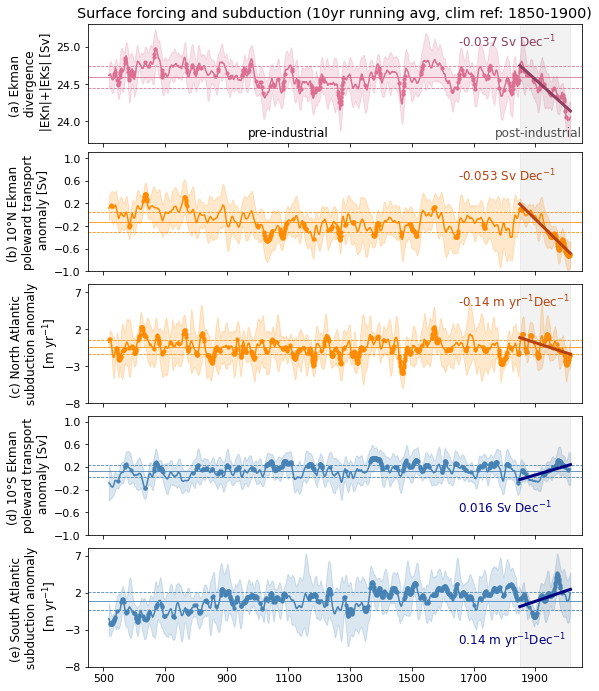

In [28]:
colorN = 'darkorange'
colorS = '#4682B4'

plt.rcParams.update({"font.size": 12, "xtick.labelsize": 11, "ytick.labelsize": 11,})
fig, ax = plt.subplots(5, 1,figsize=(8, 9.5),sharex=True,constrained_layout=True)
ax[0].set_title('Surface forcing and subduction (10yr running avg, clim ref: '+clim_ref+')') 

############## EK DIVERGENCE
ax[0].set_ylabel('(a) Ekman \n divergence \n |EKn|+|EKs| [Sv]')
x,y = stippling_1st_derivative(EKdiv_smooth2,80) # ensemble memb agreement 
confDIV = xr_CI(EKdiv_smooth, signif=0.95, dim='ensemble') # CI
ax[0].axhline(y=EKdiv_avg, c='palevioletred',lw=.8)
ax[0].axhline(y=EKdiv_avg+EKdiv_std, c='palevioletred',lw=.8,ls='--')
ax[0].axhline(y=EKdiv_avg-EKdiv_std, c='palevioletred',lw=.8,ls='--')
ax[0].fill_between(range(500,2015), confDIV.lb, confDIV.ub, color='palevioletred', alpha=.2)
ax[0].plot(range(500,2015), EKdiv_smooth.mean('ensemble'),c='palevioletred')
ax[0].scatter(x[1:],y[1:], color='palevioletred', marker='o', s=10, edgecolors='palevioletred') # stippling where the anomaly agrees on signal
ax[0].plot(range(1850,2015), DIVtrend_line, color='#8F3F60',lw=3)
ax[0].text(1650, 25, f"{round(DIVslope*10, 3)} Sv Dec$^{{-1}}$", color='#8F3F60', fontsize=12)

#ax[0].set_ylim(27,29.1)
#ax[0].set_yticks(np.arange(27,29.1,0.5))
ax[0].axvspan(1850, 2014, alpha=0.1, color='gray')
ax[0].text(1100,23.8,'pre-industrial',color='k',ha='center')
ax[0].text(1910,23.8,'post-industrial',color='#4D4D4D',ha='center')

############## NORTH
# Ekman 10N
ax[1].set_ylabel('(b) 10\N{DEGREE SIGN}N Ekman \n poleward transport \n anomaly [Sv]') #, color='darkorange')
x,y = stippling_signal_agreement(anomEKn_smooth2,80) # ensemble members agrement
confN = xr_CI(anomEKn_smooth, signif=0.95, dim='ensemble') # CI for IPSL
ax[1].axhline(y=anomEKn_avg, c=colorN,lw=.8)
ax[1].axhline(y=anomEKn_avg+anomEKn_std, c=colorN,lw=.8,ls='--')
ax[1].axhline(y=anomEKn_avg-anomEKn_std, c=colorN,lw=.8,ls='--')
ax[1].fill_between(range(500,2015), confN.lb, confN.ub, color=colorN, alpha=.2)
ax[1].plot(range(500,2015), anomEKn_smooth.mean('ensemble'),c=colorN, label='10\N{DEGREE SIGN}N')
ax[1].scatter(x[1:],y[1:], color=colorN, marker='o', s=10, edgecolors=colorN) # stippling where the anomaly agrees on signal
ax[1].plot(range(1850,2015), EKtrend_lineN, color='#B7410E',lw=3)
ax[1].text(1650, 0.6, f"{round(EKslopeN*10, 3)} Sv Dec$^{{-1}}$", color='#B7410E', fontsize=12)

ax[1].set_ylim(-1,1.1)
ax[1].set_yticks(np.arange(-1,1.1,0.4))
ax[1].axvspan(1850, 2014, alpha=0.1, color='gray')

# Subduction N
ax[2].set_ylabel('(c) North Atlantic \n subduction anomaly \n [m yr$^{-1}$]')
x,y = stippling_signal_agreement(NorthAtlanticSubduction_smooth2,80)
NorthAtlanticSubduction_conf = xr_CI(NorthAtlanticSubduction_smooth, signif=0.95, dim='record')
ax[2].axhline(y=subNorth_avg, c=colorN,lw=.8)
ax[2].axhline(y=subNorth_avg+subNorth_std, c=colorN,lw=.8,ls='--')
ax[2].axhline(y=subNorth_avg-subNorth_std, c=colorN,lw=.8,ls='--')
ax[2].fill_between(range(500,2015), NorthAtlanticSubduction_conf.lb, NorthAtlanticSubduction_conf.ub, color=colorN, alpha=.2)
ax[2].plot(range(500,2015), NorthAtlanticSubduction_smooth.mean('record'),c=colorN)
ax[2].scatter(x[1:],y[1:], color=colorN, marker='o', s=10, edgecolors=colorN) # stippling where the anomaly agrees on signal
ax[2].plot(range(1850,2015), SUBtrend_lineN, color='#B7410E',lw=3)
ax[2].text(1650, 5, f"{round(SUBslopeN*10, 2)} m yr$^{{-1}}$Dec$^{{-1}}$", color='#B7410E', fontsize=12)

ax[2].set_ylim(-8,8.1)
ax[2].set_yticks(np.arange(-8,8.1,5))
ax[2].axvspan(1850, 2014, alpha=0.1, color='gray')


############## SOUTH
# Ekman 10S
ax[3].set_ylabel('(d) 10\N{DEGREE SIGN}S Ekman \n poleward transport \n anomaly [Sv]') #, color='navy')
x,y = stippling_signal_agreement(anomEKs_smooth2,80) # ensemble members agrement
confS = xr_CI(anomEKs_smooth, signif=0.95, dim='ensemble') # CI for IPSL
ax[3].axhline(y=anomEKsINV_avg, c=colorS,lw=.8)
ax[3].axhline(y=anomEKsINV_avg+anomEKsINV_std, c=colorS,lw=.8,ls='--')
ax[3].axhline(y=anomEKsINV_avg-anomEKsINV_std, c=colorS,lw=.8,ls='--')
ax[3].fill_between(range(500,2015), confS.lb, confS.ub, color=colorS, alpha=.2)
ax[3].plot(range(500,2015), anomEKs_smooth.mean('ensemble'),c=colorS)
ax[3].scatter(x[1:],y[1:], color=colorS, marker='o', s=10, edgecolors=colorS) # stippling where the anomaly agrees on signal
ax[3].plot(range(1850,2015), EKtrend_lineS, color='navy',lw=3)
ax[3].text(1650, -0.6, f"{round(EKslopeS*10, 3)} Sv Dec$^{{-1}}$", color='navy', fontsize=12)

ax[3].set_ylim(-1,1.1)
ax[3].set_yticks(np.arange(-1,1.1,0.4))
ax[3].axvspan(1850, 2014, alpha=0.1, color='gray')

# Subduction S
ax[4].set_ylabel('(e) South Atlantic \n subduction anomaly \n [m yr$^{-1}$]')
x,y = stippling_signal_agreement(SouthAtlanticSubduction_smooth2,80)
SouthAtlanticSubduction_conf = xr_CI(SouthAtlanticSubduction_smooth, signif=0.95, dim='record')
ax[4].axhline(y=subSouth_avg, c=colorS,lw=.8)
ax[4].axhline(y=subSouth_avg+subSouth_std, c=colorS,lw=.8,ls='--')
ax[4].axhline(y=subSouth_avg-subSouth_std, c=colorS,lw=.8,ls='--')
ax[4].fill_between(range(500,2015), SouthAtlanticSubduction_conf.lb, SouthAtlanticSubduction_conf.ub, color=colorS, alpha=.2)
ax[4].plot(range(500,2015), SouthAtlanticSubduction_smooth.mean('record'),c=colorS)
ax[4].scatter(x[1:],y[1:], color=colorS, marker='o', s=10, edgecolors=colorS) # stippling where the anomaly agrees on signal
ax[4].plot(range(1850,2015), SUBtrend_lineS, color='navy',lw=3)
ax[4].text(1650, -5, f"{round(SUBslopeS*10, 2)} m yr$^{{-1}}$Dec$^{{-1}}$", color='navy', fontsize=12)

ax[4].set_ylim(-8,8.1)
ax[4].set_yticks(np.arange(-8,8.1,5))
ax[4].set_xlim(450,2050)
ax[4].set_xticks(np.arange(500,2014,200))
_=ax[4].axvspan(1850, 2014, alpha=0.1, color='gray')

fig.savefig(PathFigures+'/figure_time_series_div_ekman_sub.png', format='png', bbox_inches='tight', dpi=300, facecolor='white')